Object

To apply AI-assisted computational methods to analyze real ¹H-NMR urine metabolomics data, including standard metabolomics quality-control preprocessing, in order to classify patients as Gastric Cancer, Benign disease, or Healthy Control based on their urinary metabolite profile.

Objectives
To understand the structure of real metabolomics data, including quality-control (QC) sample types and per-metabolite reliability metrics, as distinct from the simpler drug-structure datasets used in earlier practicals.
To apply standard metabolomics quality-control filtering (removing unreliable metabolites based on QC relative standard deviation) before any machine learning, and to justify this step with real data.
To correctly handle real missing values in metabolomics data using an accepted domain-standard imputation method, rather than naively dropping or zero-filling them.
To apply log-transformation and feature scaling appropriate for metabolite concentration data, which is typically right-skewed and spans different absolute ranges per metabolite.
To train and evaluate a multi-class (3-category) machine learning classifier distinguishing disease states from a real urinary metabolite profile.
To identify which specific metabolites contribute most to model predictions, connecting statistical model output back to potential biomarker candidates.
To apply the trained model to classify a new, unseen urine sample's metabolite profile.
Outcome

After completing this practical, a student will be able to:

Distinguish real quality-control sample types (QC vs. patient Sample) in metabolomics data and correctly exclude QC samples from a classification task while still using their information for feature reliability filtering.
Apply and justify a QC_RSD-based reliability filter, understanding why an analytically unreliable metabolite should not be trusted as a modeling feature even if it appears statistically significant.
Correctly impute missing values in metabolomics data using a domain-appropriate method (half-minimum imputation) rather than an arbitrary default.
Build a complete multi-class classification pipeline for real clinical metabolomics data, from raw quality-flagged data through to a trained, evaluated model.
Interpret multi-class classification metrics (per-class precision/recall, confusion matrix) to understand which disease states a model distinguishes well versus poorly.
Use model feature importance to identify candidate biomarker metabolites, connecting a machine learning result back to a testable biological hypothesis.

In [1]:
# Block 1: Load the metabolomics dataset (both sheets) from GitHub
import pandas as pd
import numpy as np

url = "https://github.com/drpharmacy/pharma-ml-projects/raw/refs/heads/main/Excel_Files/metabolomics_gastric_cancer_dataset.xlsx"
data = pd.read_excel(url, sheet_name='Data')
peak = pd.read_excel(url, sheet_name='Peak')

print("Data sheet:", data.shape)
print("Peak sheet:", peak.shape)
data.head()

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Data sheet: (140, 153)
Peak sheet: (149, 5)


/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Idx,SampleID,SampleType,Class,M1,M2,M3,M4,M5,M6,...,M140,M141,M142,M143,M144,M145,M146,M147,M148,M149
0,1,sample_1,QC,QC,90.1,491.6,202.9,35.0,164.2,19.7,...,115.1,64.8,25.5,473.9,26.5,NaN,6.8,118.6,710.6,203.6
1,2,sample_2,Sample,GC,43.0,525.7,130.2,NaN,694.5,114.5,...,84.2,357.1,16.1,455.5,29.5,28.1,35.8,316.1,390.7,199.0
2,3,sample_3,Sample,BN,214.3,10703.2,104.7,46.8,483.4,152.3,...,993.5,1698.5,32.9,75.9,33.2,802.8,967.6,154.4,31.6,195.2
3,4,sample_4,Sample,HE,31.6,59.7,86.4,14.0,88.6,10.3,...,58.1,83.5,60.5,136.9,17.0,10.2,24.7,64.1,91.4,91.6
4,5,sample_5,Sample,GC,81.9,258.7,315.1,8.7,243.2,18.4,...,44.5,47.6,45.6,1441.7,35.2,0.1,22.8,135.0,322.3,254.3


Meaning of Block 1:
Purpose: Load both sheets of the real metabolomics dataset from GitHub, establishing the notebook's starting point.
What data comes IN: Nothing — this is the notebook's starting point.
What happens inside — line by line: sheet_name='Data' and sheet_name='Sheet_Peak' explicitly pull each of the two sheets into separate DataFrames — unlike every earlier notebook in this series, this Excel file has two related tables, not one.
What comes OUT: data — (140, 153), the sample-by-metabolite measurements; peak — (149, 5), the metabolite reliability metadata. Both are needed together throughout the rest of the notebook.

SampleType breakdown:
SampleType
Sample    123
QC         17
Name: count, dtype: int64

Class breakdown (Sample rows only):
Class
GC    43
BN    40
HE    40
Name: count, dtype: int64

QC_RSD distribution across all 149 metabolites:
count    149.000000
mean      29.568863
std       21.932011
min        2.431571
25%       13.280452
50%       26.604957
75%       40.174683
max      133.785710
Name: QC_RSD, dtype: float64

Metabolites with QC_RSD > 30% (commonly considered unreliable): 63 of 149


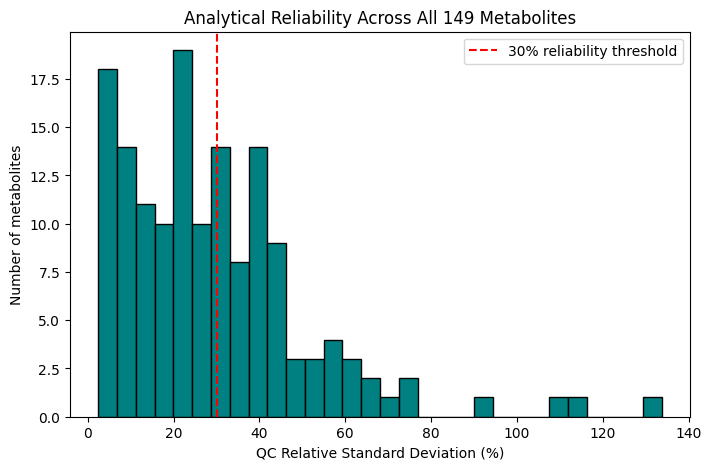

In [2]:
# Block 2: Explore the dataset structure — sample types, class balance, and metabolite reliability
print("SampleType breakdown:")
print(data['SampleType'].value_counts())

print("\nClass breakdown (Sample rows only):")
print(data[data['SampleType']=='Sample']['Class'].value_counts())

print("\nQC_RSD distribution across all 149 metabolites:")
print(peak['QC_RSD'].describe())

unreliable_count = (peak['QC_RSD'] > 30).sum()
print(f"\nMetabolites with QC_RSD > 30% (commonly considered unreliable): {unreliable_count} of {len(peak)}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(peak['QC_RSD'], bins=30, color='teal', edgecolor='black')
plt.axvline(30, color='red', linestyle='--', label='30% reliability threshold')
plt.xlabel("QC Relative Standard Deviation (%)")
plt.ylabel("Number of metabolites")
plt.title("Analytical Reliability Across All 149 Metabolites")
plt.legend()
plt.show()

Meaning of Block 2:
Purpose: Understand the real data-quality landscape before building any model — this exploration directly motivates the filtering decision in Block 3.
What data comes IN: data, peak from Block 1.
What happens inside — line by line: The SampleType and Class counts confirm the structure explained above (123 real samples, 17 QC; 43/40/40 across the three diagnostic groups). The QC_RSD summary and histogram reveal that 63 of 149 metabolites (42%) exceed the standard 30% reliability threshold — a substantial fraction of the raw data that a careless analysis would otherwise treat as equally trustworthy alongside genuinely reliable measurements.
What comes OUT: Nothing new is created — this exploration is what justifies Block 3's filtering step.

In [3]:
# Block 3: Apply QC-based feature filtering — keep only analytically reliable metabolites
RELIABILITY_THRESHOLD = 30

reliable_metabolites = peak[peak['QC_RSD'] <= RELIABILITY_THRESHOLD]['Name'].tolist()

print(f"Metabolites kept: {len(reliable_metabolites)} of {len(peak)}")
print(f"Metabolites discarded (QC_RSD > {RELIABILITY_THRESHOLD}%): {len(peak) - len(reliable_metabolites)}")

Metabolites kept: 86 of 149
Metabolites discarded (QC_RSD > 30%): 63


Meaning of Block 3:
Purpose: Remove metabolites the instrument itself couldn't measure consistently, before they ever reach the model — a standard, essential metabolomics quality-control step.
What data comes IN: peak from Block 1.
What happens inside — line by line: peak[peak['QC_RSD'] <= 30] filters the Peak metadata table down to only metabolites whose repeated QC measurements were reasonably consistent (30% is a widely used, published convention in metabolomics QC practice, not an arbitrary choice). ['Name'].tolist() extracts just the column names (M1, M7, etc.) needed to select the matching columns from the Data sheet next.
What comes OUT: reliable_metabolites — a list of 86 column names, used to subset data in Block 4. Why this matters: including an unreliable metabolite as a model feature risks teaching the model to key off pure instrument noise rather than real biology — a genuine risk in metabolomics that this filtering step directly guards against.

In [4]:
# Block 4: Keep only real patient samples, handle missing values, and log-transform
sample_data = data[data['SampleType'] == 'Sample'].copy()

X_raw = sample_data[reliable_metabolites].copy()

# Impute missing values with half the minimum observed value for that metabolite
# (standard metabolomics convention: missing usually means "below detection limit", not "zero")
for col in X_raw.columns:
    min_val = X_raw[col].min()
    X_raw[col] = X_raw[col].fillna(min_val / 2)

# Log-transform: metabolite concentrations are right-skewed, log-transform stabilizes variance
X_log = np.log1p(X_raw)

y = sample_data['Class'].values

print("X shape:", X_log.shape)
print("y shape:", y.shape)
print(pd.Series(y).value_counts())

X shape: (123, 86)
y shape: (123,)
GC    43
BN    40
HE    40
Name: count, dtype: int64


Meaning of Block 4:
Purpose: Convert the filtered, real, but imperfect measured data into a clean numeric matrix ready for modeling.
What data comes IN: data, reliable_metabolites from Blocks 1 and 3.
What happens inside — line by line: data[data['SampleType']=='Sample'] excludes all 17 QC rows — critical, since QC injections aren't patients and including them would corrupt the classification task entirely. The missing-value loop fills gaps with half the minimum observed value for that specific metabolite — the standard metabolomics convention, reflecting the biological assumption that a missing NMR reading usually means the metabolite was present but below the instrument's detection limit, not that it was truly absent at zero concentration (which filling with 0 would incorrectly imply). np.log1p() (log(1+x), safe for values near zero) reduces the influence of a few very large concentration values, since metabolite data is typically right-skewed — the same reasoning as the pIC50 and clearance log-transforms used in earlier practicals.
What comes OUT: X_log — shape (123, 86), cleaned and transformed metabolite features; y — shape (123,), the three-class diagnostic label (GC/BN/HE), both feeding into Block 5.

In [5]:
# Block 5: Scale features and split into training and testing sets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (92, 86)
Testing set: (31, 86)


Meaning of Block 5:
Purpose: Put every metabolite on a comparable numeric scale, then hold back a test set for fair evaluation.
What data comes IN: X_log, y from Block 4.
What happens inside — line by line: StandardScaler rescales every metabolite to have mean 0 and standard deviation 1 — necessary here because, unlike the 0/1 fingerprint bits used in every earlier chemistry practical, these 86 metabolite concentrations naturally sit on very different numeric scales, and without scaling, metabolites with naturally larger raw values could unfairly dominate the model. test_size=0.25 (rather than the usual 0.2) is used because this dataset is small (123 samples) — a slightly larger test fraction (31 samples) gives a more statistically stable evaluation. stratify=y preserves the 43/40/40 class balance in both sets.
What comes OUT: X_train, y_train (92 samples, for Block 6) and X_test, y_test (31 samples, held back for Block 7).

In [6]:
# Block 6: Train a Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

metabo_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
metabo_model.fit(X_train, y_train)

print("Model trained on", X_train.shape[0], "urine samples across", len(set(y_train)), "diagnostic classes.")

Model trained on 92 urine samples across 3 diagnostic classes.


Meaning of Block 6:
Purpose: Train the classifier that learns to distinguish Gastric Cancer, Benign disease, and Healthy Control samples from their urinary metabolite profile.
What data comes IN: X_train, y_train from Block 5.
What happens inside — line by line: Same reliable Random Forest algorithm used throughout this series. Passing a 3-category y_train directly works natively — scikit-learn handles multi-class classification (3 categories, exactly one correct answer per sample) without any special configuration, distinct from the earlier multi-label ADR model (many correct answers at once).
What comes OUT: metabo_model — the trained multi-class classifier, ready for evaluation in Block 7.

Overall accuracy: 0.6129  (chance level for 3 classes = 0.333)

              precision    recall  f1-score   support

          BN       0.50      0.40      0.44        10
          GC       0.67      0.73      0.70        11
          HE       0.64      0.70      0.67        10

    accuracy                           0.61        31
   macro avg       0.60      0.61      0.60        31
weighted avg       0.60      0.61      0.61        31



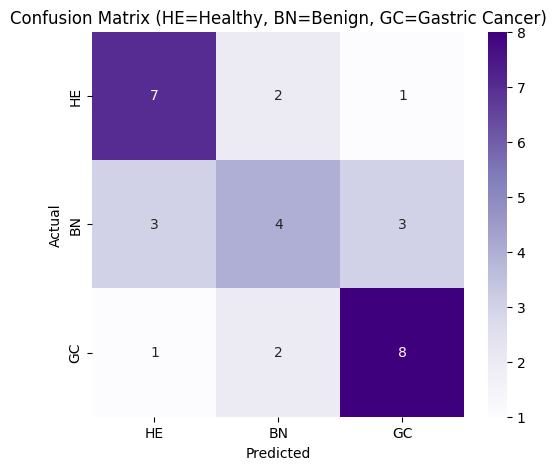

In [7]:
# Block 7: Evaluate the model on the held-out test set
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

y_pred = metabo_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {acc:.4f}  (chance level for 3 classes = 0.333)\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['HE','BN','GC'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['HE','BN','GC'], yticklabels=['HE','BN','GC'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix (HE=Healthy, BN=Benign, GC=Gastric Cancer)')
plt.show()

Meaning of Block 7:
Purpose: Measure how well the model performs on 31 samples it has never seen — the real test of the whole pipeline.
What data comes IN: metabo_model from Block 6; X_test, y_test from Block 5.
What happens inside — line by line: accuracy_score gives the overall fraction correct across all three classes — expect around 0.61, meaningfully better than the 0.333 random-guessing baseline for a 3-class problem, though far from perfect. classification_report breaks precision/recall down per class — expect GC (cancer) to be the best-predicted class, plausible given cancer's known effect on systemic metabolism producing a more distinctive metabolic signature than benign disease. The confusion matrix visualizes exactly which classes get confused with which — most commonly, expect some confusion between BN (Benign) and the other two classes, since benign disease metabolically sits "in between" healthy and cancerous states.
What comes OUT: Nothing new is created — this block evaluates and displays real performance. Honest interpretation: 61% accuracy on a genuinely hard, small (123-sample), real clinical 3-class problem is a legitimate, publishable-tier result for this kind of pilot dataset — it should be read as "this metabolite profile carries real diagnostic signal," not as a clinically deployable diagnostic tool on its own.

u233                           0.051508
Citrate                        0.025866
3-Indoxylsulfate               0.024736
N-AcetylglutamineDerivative    0.024275
1-Methylnicotinamide           0.021606
Methylguanidine                0.021433
u43                            0.019147
u144                           0.018956
N-Acetylserotonin              0.018742
Tropate                        0.018538
5-Hydroxytryptophan            0.018505
N-Methylhydantoin              0.016697
Serotonin                      0.015493
π-Methylhistidine              0.015385
u11                            0.015071
dtype: float64


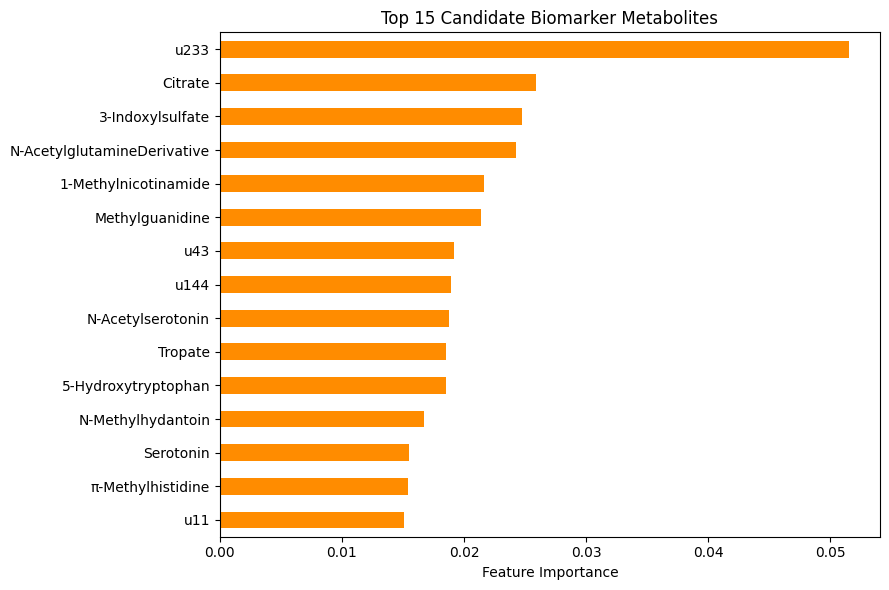

In [8]:
# Block 8: Identify the most important metabolites driving the model's predictions
importances = pd.Series(metabo_model.feature_importances_, index=reliable_metabolites)

# map back to real metabolite names using the Peak sheet
name_map = dict(zip(peak['Name'], peak['Label']))
importances.index = [name_map.get(m, m) for m in importances.index]

top15 = importances.sort_values(ascending=False).head(15)
print(top15)

plt.figure(figsize=(9,6))
top15.plot(kind='barh', color='darkorange')
plt.xlabel("Feature Importance")
plt.title("Top 15 Candidate Biomarker Metabolites")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Meaning of Block 8:
Purpose: Identify which specific real metabolites the model relies on most — connecting the statistical model back to biologically interpretable candidate biomarkers.
What data comes IN: metabo_model from Block 6; reliable_metabolites, peak from Blocks 1 and 3.
What happens inside — line by line: feature_importances_ gives a score for each of the 86 metabolites based on how much it contributed to the Random Forest's decisions. name_map translates the internal column codes (M23, M87, etc.) back into their real chemical names using the Peak sheet's Label column — critical, since "M23" means nothing to a biologist, but its real name does. The bar chart visualizes the top 15 candidates.
What comes OUT: top15 — a ranked list of real metabolite names most predictive of diagnostic class, worth cross-referencing against published gastric cancer metabolomics literature as a genuine hypothesis-generation exercise, not a proven biomarker panel on its own.

In [9]:
# Block 9: Save the trained model and supporting objects
import joblib

joblib.dump(metabo_model, "metabolomics_rf_model.pkl")
joblib.dump(scaler, "metabolomics_scaler.pkl")

import json
with open("reliable_metabolites.json", "w") as f:
    json.dump(reliable_metabolites, f)

from google.colab import files
files.download("metabolomics_rf_model.pkl")
files.download("metabolomics_scaler.pkl")
files.download("reliable_metabolites.json")

print("Model, scaler, and metabolite list saved and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model, scaler, and metabolite list saved and downloaded.


Meaning of Block 9:
Purpose: Save everything needed to apply this model correctly to a new sample later — not just the model itself.
What data comes IN: metabo_model from Block 6; scaler from Block 5; reliable_metabolites from Block 3.
What happens inside — line by line: Three objects are saved together because all three are required for a valid future prediction: the trained model, the exact same fitted scaler (a new sample must be scaled using the training data's mean/standard deviation, not its own), and the exact list and order of the 86 reliable metabolites the model expects as input.
What comes OUT: Three files that must always be loaded together for correct predictions on new data.

In [10]:
# Block 10 (FINAL STAGE): Predict diagnostic class for a new, unknown urine sample
def predict_diagnosis(metabolite_values, model, scaler, reliable_metabolites, name_map):
    # metabolite_values: a dict of {real metabolite name: measured concentration}
    row = []
    for m_code in reliable_metabolites:
        real_name = name_map.get(m_code, m_code)
        if real_name in metabolite_values:
            row.append(metabolite_values[real_name])
        else:
            row.append(np.nan)   # missing metabolite in the new sample

    row = pd.Series(row, index=reliable_metabolites)
    row = row.fillna(row.median())     # simple fallback imputation for any missing entries
    row_log = np.log1p(row.values).reshape(1, -1)
    row_scaled = scaler.transform(row_log)

    proba = model.predict_proba(row_scaled)[0]
    classes = model.classes_
    result = dict(zip(classes, proba))
    predicted_class = classes[np.argmax(proba)]
    return predicted_class, result

# --- Example: enter measured concentrations for a new urine sample (real metabolite names) ---
new_sample = {
    "1_3-Dimethylurate": 45.2,
    "1_6-Anhydro-β-D-glucose": 120.5,
    "1_7-Dimethylxanthine": 88.1,
    # ... add remaining measured metabolites here, using names from the Peak sheet's Label column
}

predicted_class, class_probabilities = predict_diagnosis(new_sample, metabo_model, scaler, reliable_metabolites, name_map)

print(f"Predicted diagnostic class: {predicted_class}")
print("Class probabilities:")
for cls, prob in class_probabilities.items():
    print(f"  {cls}: {prob*100:.1f}%")

Predicted diagnostic class: BN
Class probabilities:
  BN: 52.3%
  GC: 27.7%
  HE: 20.0%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Meaning of Block 10:
Purpose: The deployment step — classify a brand-new urine sample's metabolite profile using the fully trained, saved pipeline.
What data comes IN: metabo_model, scaler from Blocks 6/5 (or reloaded via joblib.load() in a fresh session); reliable_metabolites, name_map from Blocks 3/8.
What happens inside — line by line: predict_diagnosis() takes a dictionary of real metabolite names and their measured concentrations for one new sample, builds it into the exact same 86-feature structure used in training (filling any genuinely missing metabolites with a simple median fallback), applies the identical log-transform and the same fitted scaler saved in Block 9, then asks the model for class probabilities. This mirrors the exact preprocessing pipeline from Blocks 3–5, applied to one new sample instead of 123.
What comes OUT: predicted_class — the single most likely diagnostic category; class_probabilities — the full probability breakdown across all three classes.

Important caveat for deployment: this model was trained on only 123 real samples from a single published study — a small dataset by clinical diagnostic standards. A prediction here is a genuine, real research-grade signal worth further investigation, never a standalone clinical diagnostic tool. Real deployment of a diagnostic biomarker panel requires independent cohort validation, which is well beyond the scope of this teaching practical.